(bayes-workflow-notebook)=
# Modellazione bayesiana

L'obiettivo di questo Capitolo è di introdurre il quadro concettuale dela modellizzazione bayesiana.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import beta
from scipy.stats import uniform
from scipy.special import factorial

In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## Inferenza Statistica

L'inferenza statistica è un processo che armonizza deduzione e induzione per esaminare dati campionari, al fine di inferire le caratteristiche di una popolazione più estesa. Prendiamo come esempio l'altezza di cinque individui selezionati casualmente. Un meccanismo sottostante, denominato "processo T", determina le loro altezze. Questo processo è ciò che intendiamo comprendere o stimare mediante l'inferenza statistica. Tuttavia, la natura esatta di T rimane spesso ignota e complessa, celata dietro la variabilità osservata nei nostri dati. Questa variabilità può essere attribuita a due cause principali: la variabilità intrinseca del fenomeno in esame (ad esempio, differenze genetiche o ambientali) e le limitazioni delle nostre capacità di osservazione e analisi.

{cite:t}`McElreath_rethinking` introduce il concetto di "Grande Mondo" per rappresentare l'infinità di processi che potrebbero giustificare le nostre osservazioni. Data questa infinità, diventa impraticabile effettuare inferenze dirette su tutte le possibili proprietà del Grande Mondo. Ci orientiamo quindi verso il "Piccolo Mondo", una semplificazione che considera solo un insieme finito di modelli e parametri ritenuti pertinenti per il nostro studio. Nel caso dell'altezza, potremmo ipotizzare un modello probabilistico semplice, per cui l'altezza segue una distribuzione normale caratterizzata da media (µ) e deviazione standard (σ), mirando a stimare questi parametri sconosciuti.

La collezione di distribuzioni di probabilità, ottenuta variando i parametri del nostro modello nel Piccolo Mondo, è conosciuta come la funzione di verosimiglianza. Spesso, però, questo insieme risulta troppo ampio per essere gestibile. Fortunatamente, la nostra conoscenza pregressa o le convinzioni sul fenomeno in studio ci aiutano a restringere le possibilità.

Nell'inferenza bayesiana, questa conoscenza previa è formulata tramite una densità di probabilità a priori, assegnando un peso ai possibili parametri del modello secondo le nostre convinzioni iniziali. La regola di Bayes è al centro dell'inferenza bayesiana, permettendoci di aggiornare queste convinzioni in luce dei nuovi dati osservati. Questo processo ci fornisce la probabilità a posteriori dei parametri, offrendo una stima più precisa del processo generativo dei dati, T.

In conclusione, l'inferenza statistica ci avvicina alla comprensione di fenomeni complessi modellando le osservazioni attraverso processi semplificati nel "Piccolo Mondo". Mediante l'inferenza bayesiana, integrando le conoscenze pregresse con i nuovi dati, affiniamo le nostre stime per una comprensione approfondita del vero processo sottostante.

La celebre affermazione di {cite:t}`boxallmodels` "Tutti i modelli sono sbagliati, ma alcuni sono utili" evidenzia l'essenza dell'inferenza statistica. Non aspiriamo a un "modello perfetto" che catturi ogni dettaglio del "Grande Mondo", ma piuttosto a identificare modelli del "Piccolo Mondo" efficaci nelle previsioni sul fenomeno studiato.

La statistica ci fornisce gli strumenti per costruire, valutare e selezionare modelli basati sull'inferenza bayesiana, consentendoci di aggiornare e perfezionare i nostri modelli in risposta alle nuove informazioni. Questo processo ci guida verso modelli "utili", che, pur non essendo perfetti, ci permettono di fare previsioni accurate e di approfondire la nostra comprensione del fenomeno di interesse.

### I Metodi Bayesiani in Psicologia

I metodi bayesiani hanno trovato terreno fertile anche nel campo della psicologia. L'adozione di approcci bayesiani in questo ambito ha conosciuto un'accelerazione significativa, merito anche della diffusione di risorse educative e di pubblicazioni che ne hanno facilitato l'integrazione nell'analisi dei dati psicologici. Autori come {cite:t}`albert_2019prob`, {cite:t}`Johnson2022bayesrules`, {cite:t}`McElreath_rethinking`, {cite:t}`doingbayesian`, hanno fornito agli psicologi gli strumenti necessari per applicare in modo efficace l'inferenza bayesiana ai dati psicologici. 

### Elementi Fondamentali della Modellazione Statistica Bayesiana

I pilastri della modellazione statistica bayesiana sono le variabili casuali, le distribuzioni a priori e posteriori, e il processo di aggiornamento bayesiano.

- **Variabili casuali**: Elementi fondamentali della modellazione bayesiana, le variabili casuali ci permettono di formulare e quantificare le relazioni probabilistiche tra le diverse dimensioni del fenomeno sotto indagine. Attraverso di esse, si possono definire modelli che catturano la complessità e l'incertezza intrinseca dei dati analizzati.

- **Distribuzioni di probabilità**: Strumenti essenziali per l'espressione quantitativa dell'incertezza e delle conoscenze pregresse riguardo ai parametri del modello. Le *distribuzioni priori* codificano le nostre convinzioni iniziali, prima di esaminare i dati, mentre le *distribuzioni posteriori* si formano dall'integrazione delle evidenze appena raccolte con le informazioni già note, risultato dell'applicazione dell'aggiornamento bayesiano.

- **Aggiornamento bayesiano**: Meccanismo attraverso cui le distribuzioni priori vengono raffinate alla luce dei nuovi dati, migliorando così le stime dei parametri e diminuendo l'incertezza associata. Questo processo iterativo amplifica la nostra comprensione dei fenomeni studiati e facilita l'adattamento dei modelli alle nuove informazioni che emergono.

La creazione di un modello bayesiano segue un iter metodologico strutturato in tre fasi principali:

1. **Progettazione del modello**: Questa fase iniziale prevede la formalizzazione delle conoscenze e delle ipotesi relative al meccanismo generatore dei dati in un modello matematico. È un passaggio che richiede un'analisi approfondita del fenomeno di interesse e un'attenta considerazione delle variabili chiave e delle loro interconnessioni. La selezione delle distribuzioni priori, che riflette le nostre convinzioni iniziali riguardo alle variabili non osservabili, rappresenta un aspetto critico di questa fase.

2. **Applicazione del teorema di Bayes**: La seconda fase si focalizza sull'uso del teorema di Bayes per aggiornare le credenze priori con le evidenze ottenute dai nuovi dati. Tale processo trasforma il modello preliminare in una struttura che incorpora tanto le conoscenze preesistenti quanto le nuove informazioni derivanti dall'analisi dei dati. La distribuzione a posteriori risultante fornisce un aggiornamento quantitativo delle stime dei parametri, permettendo una stima più precisa dell'incertezza residua e delle probabilità associate alle varie ipotesi.

3. **Valutazione critica del modello**: L'ultima fase implica un'analisi critica dell'adeguatezza del modello, esaminando la coerenza dei risultati ottenuti e la robustezza del modello rispetto a variazioni nelle ipotesi di base. Tale fase può estendersi al confronto tra modelli concorrenti, avvalendosi di metriche specifiche come l'informazione di Akaike bayesiana, al fine di identificare il modello che meglio si accorda con i dati e le teorie di riferimento. Questo processo di confronto e selezione è indispensabile per garantire che il modello finale sia non solo appropriato ma anche il più informativo e accurato possibile.

Questo approccio metodologico, che si estende dalla concezione iniziale fino all'analisi finale, delinea il *flusso di lavoro bayesiano* come un iter di apprendimento e affinamento costante. Nei capitoli successivi, esploreremo dettagliatamente ciascuna di queste fasi, illustrando il processo standard che caratterizza il workflow bayesiano {cite:p}`baribault2023troubleshooting`.

## Riesame del Teorema di Bayes

Prima di approfondire il flusso di lavoro bayesiano, è opportuno rivisitare il teorema di Bayes, questa volta contestualizzandolo nel quadro delle densità di probabilità. In questa prospettiva, il teorema di Bayes articola il meccanismo con cui le nostre credenze iniziali, o probabilità a priori, sono aggiornate in funzione dei nuovi dati osservati. La formula fondamentale del teorema di Bayes, espressa in termini di densità di probabilità, è la seguente:

$$
p(\theta \mid \text{data}) = \frac{p(\text{data} \mid \theta)p(\theta)}{p(\text{data})} \propto p(\text{data} \mid \theta)p(\theta),
$$

dove:
- $\theta$ indica l'insieme dei parametri di interesse (per esempio, i coefficienti di una regressione).
- $p(\theta \mid \text{data})$ è la distribuzione posteriore dei parametri, risultato dell'aggiornamento della distribuzione a priori $p(\theta)$ mediante la funzione di verosimiglianza $p(\text{data} \mid \theta)$.
- $p(\text{data})$ rappresenta la probabilità marginale dei dati, agendo da costante di normalizzazione per garantire che la distribuzione posteriore integri a 1.

Nell'ambito bayesiano, si utilizzano le distribuzioni posteriori aggiornate dei parametri per l'inferenza, ad esempio per calcolare la probabilità che un parametro si trovi entro un determinato intervallo.

Le distribuzioni a priori, indicate con $p(\theta)$, sono basate su risultati precedenti, meta-analisi, l'expertise di esperti, o possono assumere la forma di "distribuzioni di regolarizzazione" non informative. Un vantaggio significativo delle distribuzioni a priori emerge quando si lavora con campioni di dati di piccole dimensioni; in tali contesti, le distribuzioni a priori di regolarizzazione possono esercitare un effetto moderatore, attenuando le fluttuazioni causate dalla limitata numerosità del campione.

Nel definire il processo di modellazione, consideriamo una variabile casuale $Y$, con un valore osservato $y$. Ad esempio, il punteggio ottenuto da uno studente in un test di psicometria può essere modellato come $Y$, che assume uno specifico valore $y$ una volta osservato il punteggio. Per spiegare come i dati osservati $y$ siano generati, specificiamo un modello di probabilità, il cosiddetto *processo generatore di dati* (DGP).

Il parametro $\theta$ caratterizza il modello di probabilità di interesse, potendo essere uno scalare (come media o varianza) o un vettore (ad esempio, coefficienti di regressione). L'obiettivo dell'inferenza statistica è stimare questi parametri sconosciuti a partire dai dati. A differenza dell'inferenza frequentista, che considera $\theta$ come fisso ma sconosciuto, l'inferenza bayesiana tratta $\theta$ come una variabile casuale soggetta a una distribuzione di probabilità a priori.

In questo contesto, la probabilità congiunta di parametri e dati si calcola come funzione della distribuzione condizionale dei dati dati i parametri e della distribuzione a priori dei parametri. La distribuzione posteriore di $\theta$ dato $y$ si deriva moltiplicando la funzione di verosimiglianza dei dati $p(y \mid \theta)$ per la distribuzione a priori $p(\theta)$, e normalizzando per $p(y)$. Nei modelli complessi con numerosi parametri, l'elaborazione della distribuzione posteriore può richiedere tecniche computazionali avanzate.

La distribuzione congiunta di parametri e dati si esprime così:

$$ 
p(\theta, y) = p(y \mid \theta)p(\theta). 
$$

Applicando il teorema di Bayes, otteniamo:

$$ 
p(\theta \mid y) = \frac{p(y \mid \theta)p(\theta)}{p(y)},
$$

ponendo in evidenza che $p(y \mid \theta)$ è la funzione di verosimiglianza e questa equazione incarna il fulcro dell'inferenza bayesiana, distinguendola dalla statistica frequentista.

Per variabili discrete, la probabilità marginale dei dati si calcola sommando su tutti i possibili valori di $\theta$, mentre per le variabili continue si utilizza l'integrazione:

$$ 
p(y) = \int p(y \mid \theta)p(\theta)d\theta.
$$

La solidità dell'approccio bayesiano è supportata dalle ricerche di Cox e Savage, che hanno dimostrato come, data la rappresentazione di convinzioni razionali attraverso $p(\theta)$ e $p(y \mid \theta)$, la regola di Bayes costituisca il metodo più adeguato per aggiornare tali convinzioni alla luce di nuove informazioni.

## Costruzione del Modello dell'Aggiornamento Bayesiano 

Per spiegare il concetto di aggiornamento bayesiano, {cite:t}`McElreath_rethinking` propone il seguente esempio. Supponiamo di avere un mappamondo e di volere stimare qual è la proporzione coperta d'acqua del globo. Per stimare questa proporzione eseguiamo il seguente esperimento casuale: lanciamo in aria il mappamondo e poi lo afferriamo quando cade. Registriamo se la superficie sotto il nostro indice destro è terra o acqua. Ripetiamo questa procedura un certo numero di volte e calcoliamo la proporzione di volte in cui abbiamo osservato "acqua". In ogni lancio, ogni valore della proporzione sconosciuta $p$ può essere più o meno plausibile, date le evidenze fornite dai lanci precedenti.

Un modello bayesiano inizia assegnando un insieme di plausibilità iniziali a ciascuno dei possibili valori $p$, dette plausibilità priori. Poi, queste plausibilità vengono aggiornate alla luce dei dati raccolti, producendo le plausibilità posteriori. Questo processo di aggiornamento è una forma di apprendimento, conosciuto come aggiornamento bayesiano.

Nell'esempio di {cite:t}`McElreath_rethinking`, supponiamo che il nostro modello bayesiano assegni inizialmente la stessa plausibilità a ogni possibile valore di $p$ (proporzione di acqua). Ora, osserviamo il primo grafico in alto a sinistra nella figura generata dallo script. La linea tratteggiata orizzontale rappresenta la plausibilità iniziale di ciascun possibile valore di $p$. Dopo aver visto il primo lancio, che risulta in “W” (acqua), il modello aggiorna le plausibilità alla linea continua. La plausibilità che $p$ = 0 scende a zero, indicando che è "impossibile" non avere acqua, dato che abbiamo osservato almeno una traccia di acqua sul globo. Allo stesso modo, la plausibilità che $p$ > 0.5 aumenta, poiché non c'è ancora evidenza di terra sul globo, quindi le plausibilità iniziali vengono modificate per essere coerenti con questa osservazione. Tuttavia, le differenze nelle plausibilità non sono ancora molto grandi, poiché le evidenze raccolte finora sono limitate. In questo modo, la quantità di evidenza vista finora si riflette nelle plausibilità di ciascun valore di $p$: la plausibilità che $p$ sia 0 è zero e la plausibilità che $p$ sia 1 è massima. Quindi, la distribuzione a posteriori di $p$ è rappresentata dalla linea continua che collega questi due estremi.

Nei grafici successivi, vengono introdotti ulteriori campioni dal globo, uno alla volta. Ogni curva tratteggiata rappresenta la curva continua dal grafico precedente, spostandosi da sinistra a destra e dall'alto in basso. La seconda osservazione è "terra" (L). La distribuzione a priori è la linea tratteggiata del secondo pannello e la distribuzione a postriori è la linea curva. Otteniamo questa curva perché assegniamo una verosimiglianza 0 agli eventi $p$ = 0 (abbiamo osservato "acqua") e $p$ = 1 (abbiamo osservato "terra"). In due lanci abbiamo osservato una volta "terra" e una volta "acqua". Dunque la plausibilità che $p$ = 0.5 è massima. Da cui la curva che abbiamo disegnato. 

Il terzo lancio del mappamondo produce nuovamente "acqua". Quindi a questo punto il valore più plausibile di $p$ è 0.75. modifichiamo dunque la distribuzione a priori (linea tratteggiata nel terzo pannello) in modo da rappresentare le nostre nuove conoscenze, come indicato dalla linea continua.

Ogni volta che viene osservato un "W", il picco della curva di plausibilità si sposta a destra, verso valori maggiori di $p$. Ogni volta che viene osservato un "L" (terra), si sposta nella direzione opposta. L'altezza massima della curva aumenta con ogni campione, significando che la plausibilità complessiva (1) viene ridistribuita ad un numero minore di valori di $p$ i quali accumulano una maggiore plausibilità man mano che aumenta la quantità di evidenza. Con l'aggiunta di ogni nuova osservazione, la curva viene aggiornata in modo coerente con tutte le osservazioni precedenti.

È importante notare che ogni set aggiornato di plausibilità diventa la plausibilità iniziale per l'osservazione successiva. Ogni conclusione è il punto di partenza per l'inferenza futura. Questo processo di aggiornamento funziona anche al contrario: conoscendo l'ultimo set di plausibilità e l'ultima osservazione, è possibile matematicamente dedurre la curva di plausibilità precedente. I dati potrebbero essere presentati al modello in qualsiasi ordine, o anche tutti insieme. Nella maggior parte dei casi, i dati verranno considerati tutti insieme per comodità, ma è importante capire che ciò rappresenta solo l'abbreviazione di un processo di apprendimento iterato.

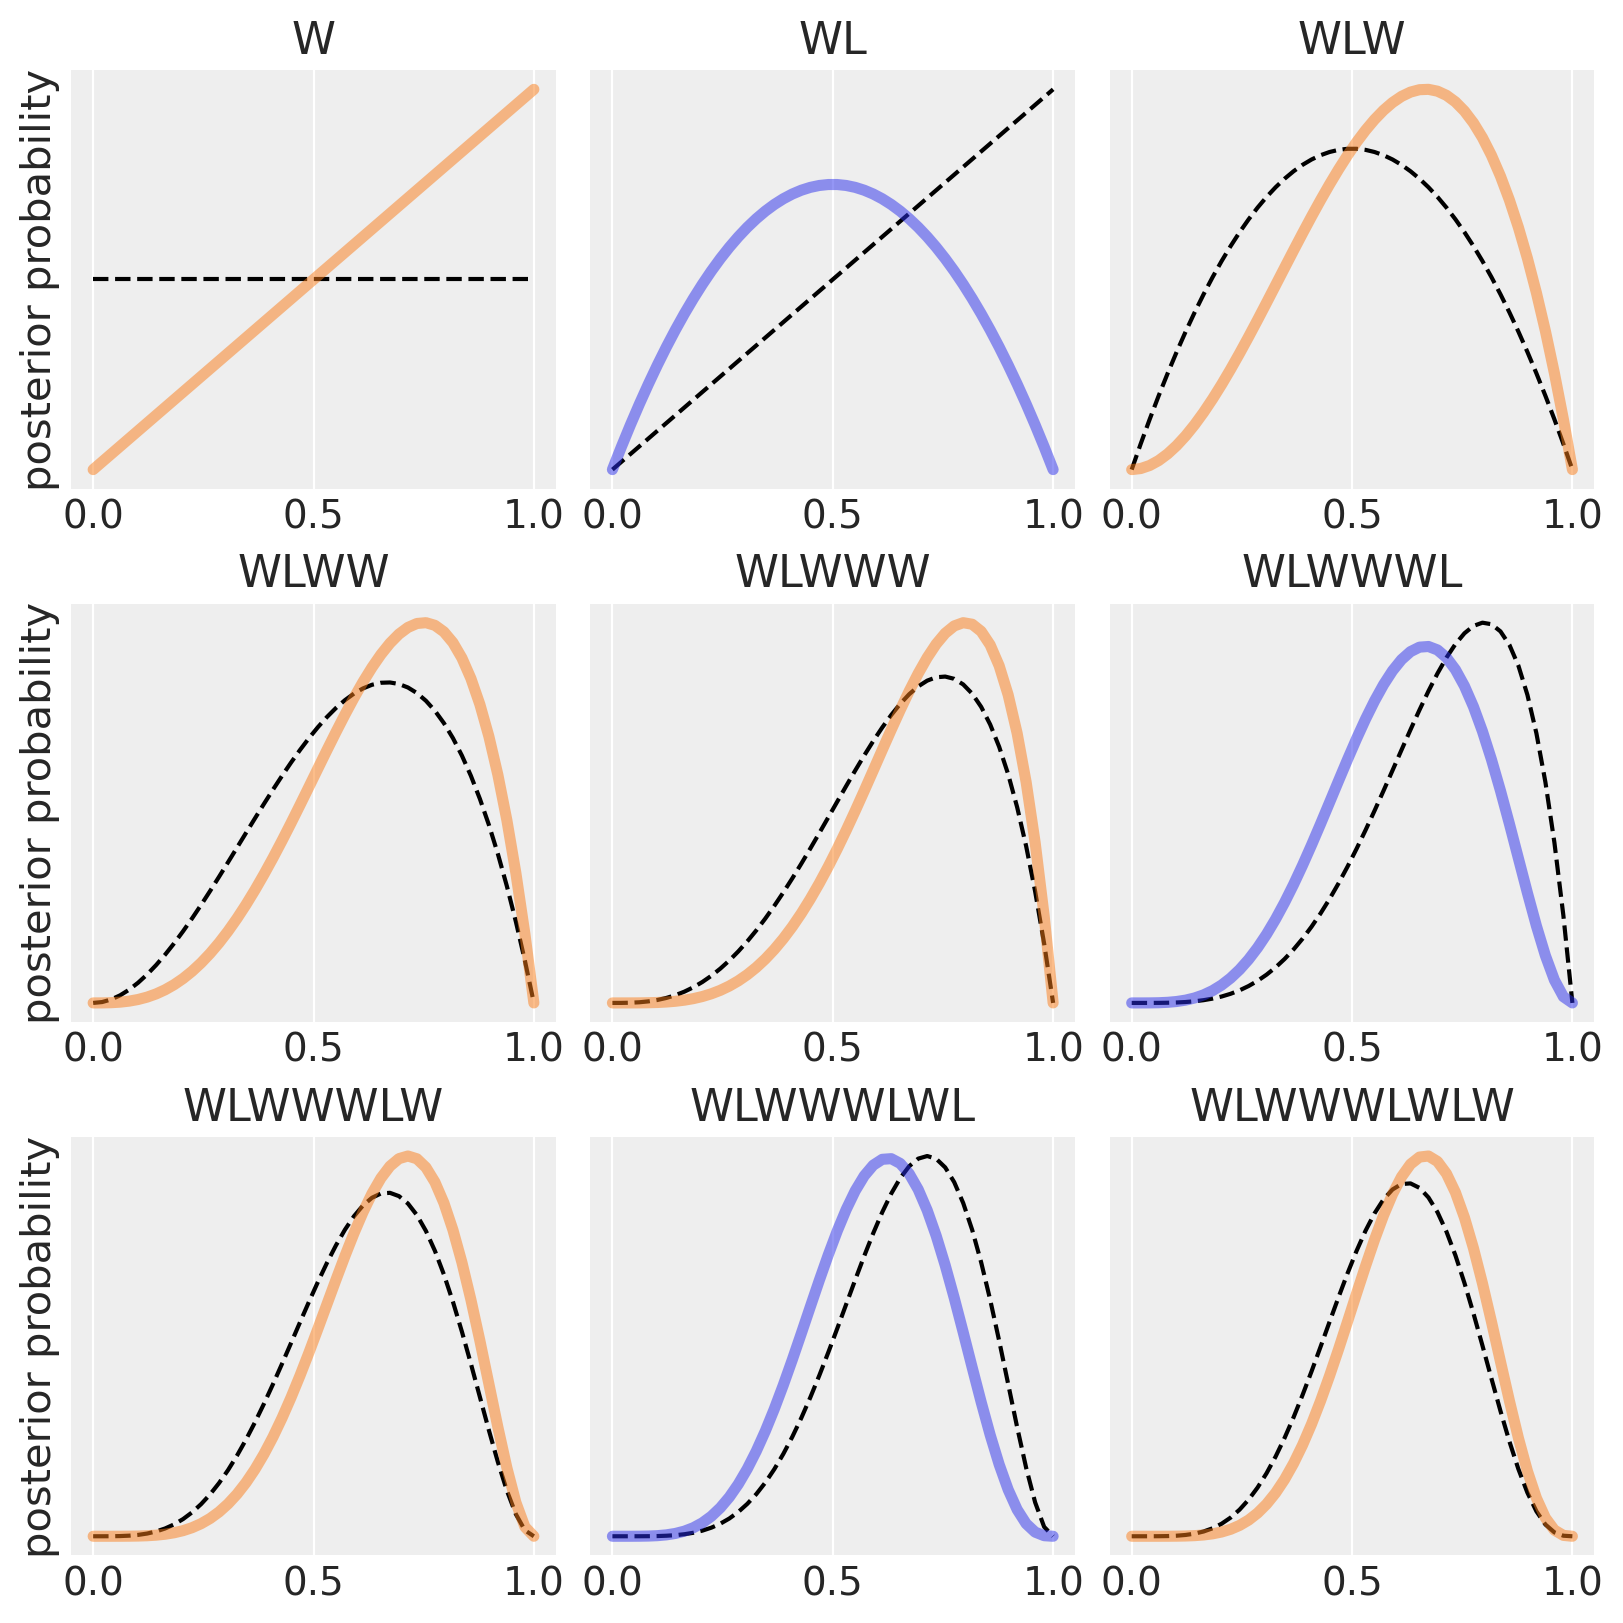

In [3]:
def beta(W, L, p):
    return factorial(W + L + 1) / (factorial(W) * factorial(L)) * p ** W * (1-p) ** L


def plot_beta_from_observations(observations: str, resolution: int = 50, **plot_kwargs):
    """Calcualte the posterior for a string of observations"""
    n_W = len(observations.replace("L", ""))
    n_L = len(observations) - n_W
    proportions = np.linspace(0, 1, resolution)
        
    probs = beta(n_W, n_L, proportions)
    plt.plot(proportions, probs, **plot_kwargs)
    plt.yticks([])
    plt.title(observations)
    

# Tossing the globe
observations = "WLWWWLWLW"
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
for ii in range(9):
    ax = axs[ii // 3][ii % 3]
    plt.sca(ax)
    # Plot previous
    if ii > 0:
        plot_beta_from_observations(observations[:ii], color='k', linestyle='--')
    else:
        # First observation, no previous data
        plot_beta_from_observations('', color='k', linestyle='--')
        
    color = 'C1' if observations[ii] == 'W' else 'C0'
    plot_beta_from_observations(observations[:ii+1], color=color, linewidth=4, alpha=.5)
    
    if not ii % 3:
        plt.ylabel("posterior probability")

Il lettore attento si sarà chiesto se la curva continua dell'ultimo pannello non sia in realtà identica alla funzione di verosimiglianza binomiale con 6 successi in 9 prove -- si veda il capitolo {ref}`notebook-likelihood`. In effetti è proprio così.

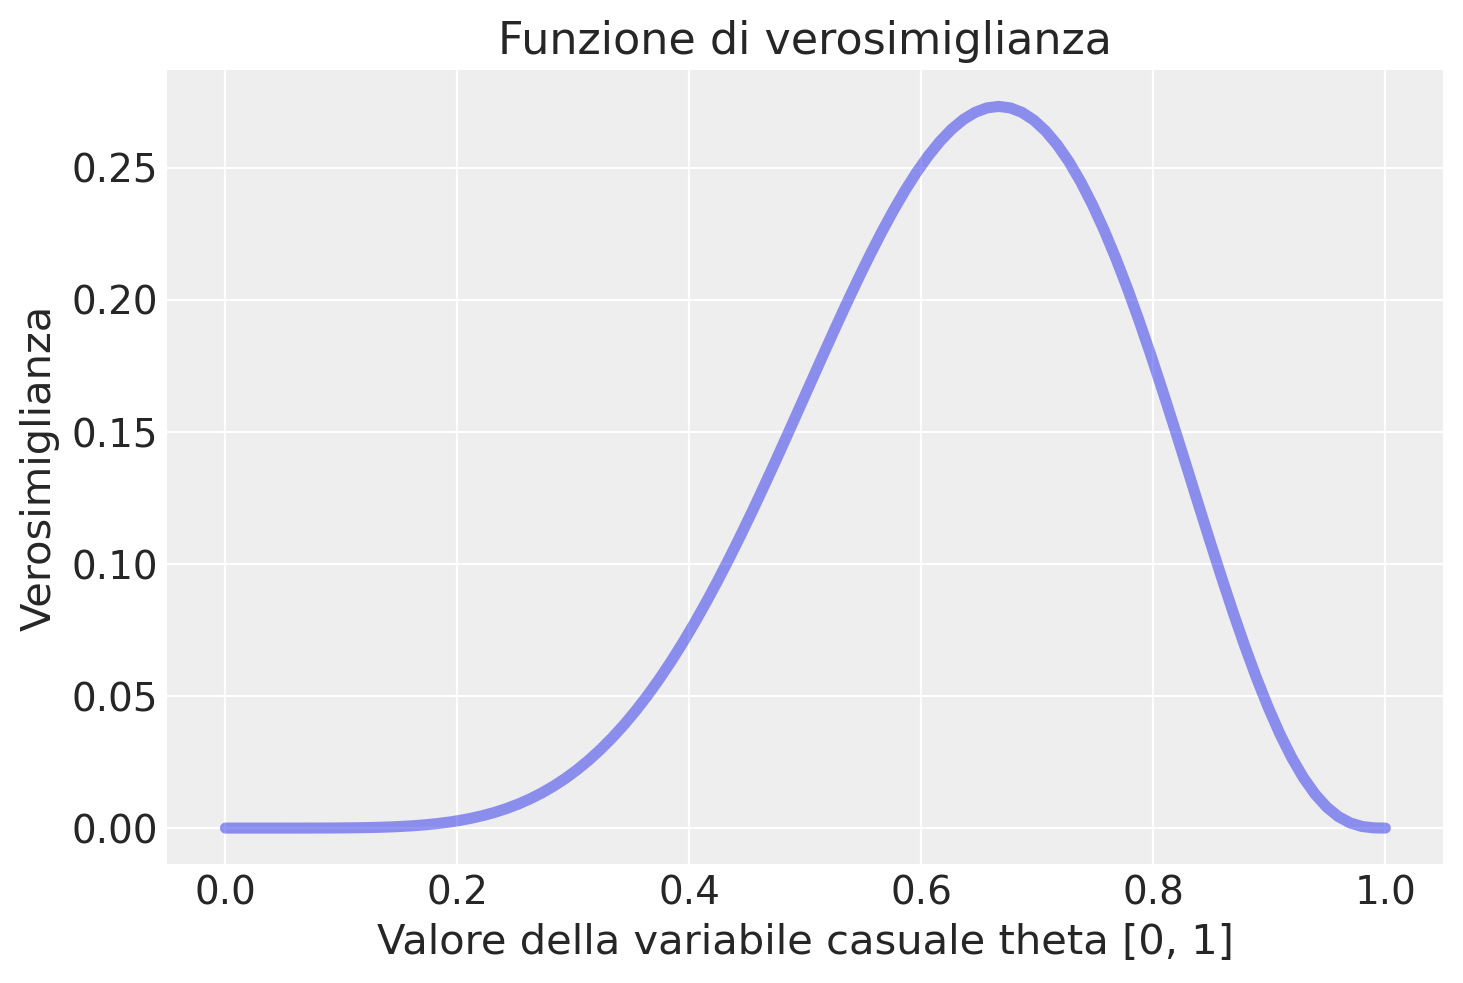

In [4]:
y = 6
n = 9
theta = np.linspace(0.0, 1.0, num=100)

like = stats.binom.pmf(y, n, theta)

plt.plot(theta, like, "-", linewidth=4, alpha=.5)
plt.title("Funzione di verosimiglianza")
plt.xlabel("Valore della variabile casuale theta [0, 1]")
_ = plt.ylabel("Verosimiglianza")

### Il flusso di lavoro bayesiano

Metaforicamente descritto come "girare la manovella bayesiana", il flusso di lavoro bayesiano è composto da diverse fasi.

1. **Studio di Simulazione**: Questa fase prevede la generazione di dati sintetici che riproducono il contesto di ricerca. Questo aiuta a valutare la robustezza del disegno sperimentale e ad assicurare che il modello sia adeguato.

2. **Raccolta e Identificazione dei Dati**: Qui si acquisiscono e analizzano i dati reali, assicurandosi che siano appropriati per le analisi successive.

3. **Selezione del Modello Statistico**: In questa fase si formula un modello statistico che rappresenta le teorie e le ipotesi alla base della ricerca, basandosi su una solida comprensione del fenomeno e su principi statistici.

4. **Definizione delle Distribuzioni a Priori**: Si stabiliscono le distribuzioni a priori dei parametri del modello, basandosi su conoscenze pregresse e un ragionamento teorico robusto.

5. **Calcolo delle Distribuzioni a Posteriori**: Utilizzando metodi analitici o tecniche di campionamento come le Catene di Markov Monte Carlo (MCMC), si derivano le distribuzioni a posteriori dei parametri.

6. **Risoluzione dei Problemi e Diagnostica**: In questa fase si eseguono controlli per assicurare la convergenza del modello e la validità delle inferenze, utilizzando metriche e diagnosi specializzate.

7. **Controlli di Coerenza**: Oltre alla diagnostica tecnica, si valuta la coerenza e la plausibilità del modello rispetto ai dati e al contesto teorico, incluso un esame predittivo a posteriori.

8. **Interpretazione e Comunicazione dei Risultati**: Infine, i risultati vengono interpretati nel contesto della teoria sottostante e comunicati in modo chiaro, integrandoli nell'ambito più ampio della comprensione del fenomeno in studio.

Questo processo iterativo mira a ottenere inferenze valide, fornendo una base solida per la ricerca scientifica. Una rappresentazione visiva di questo flusso di lavoro bayesiano è illustrata nella figura tratta dall'articolo di {cite:t}`baribault2023troubleshooting`.


```{figure} ../images/bayesian_workflow.png
---
height: 550px
name: bayes-workflow-fig
---
Una rappresentazione abbreviata del flusso di lavoro bayesiano. L'output del modello che non supera il filtro (che rappresenta i necessari controlli computazionali e di coerenza) deve essere respinto. È necessario migliorare la specifica del modello in modo che l'output possa  superare tutti i controlli. Solo allora il modello bayesiano può essere utilizzato come base per l'inferenza. (Figura tratta da {cite:t}`baribault2023troubleshooting`).
```

## Notazione

Per chiarire la notazione, nel seguito utilizzeremo $y$ per rappresentare i dati osservati e $\theta$ per indicare i parametri sconosciuti di un modello statistico. Entrambi, $y$ e $\theta$, saranno trattati come variabili casuali. Utilizzeremo invece $x$ per denotare le quantità note, come ad esempio i predittori di un modello lineare.

Al fine di rappresentare in modo più conciso i modelli probabilistici, adotteremo una notazione specifica. Ad esempio, anziché scrivere la distribuzione di probabilità di $\theta$ come $p(\theta) = Beta(1, 1)$, scriveremo semplicemente $\theta \sim Beta(1, 1)$. Il simbolo "$\sim$" viene comunemente letto come "segue la distribuzione di". Possiamo anche interpretarlo nel senso che $\theta$ è un campione casuale estratto dalla distribuzione Beta(1, 1). Analogamente, la verosimiglianza di un modello binomiale sarà espressa come $y \sim \text{Bin}(n, \theta)$, dove "$\sim$" indica che $y$ segue una distribuzione binomiale con parametri $n$ e $\theta$. Questa notazione semplifica la rappresentazione dei modelli probabilistici, rendendo più chiara la relazione tra i dati, i parametri e le distribuzioni di probabilità coinvolte nelle analisi statistiche.

## Metodi di Stima della Distribuzione a Posteriori

La formulazione completa della distribuzione posteriore è data da:

$$
p(\theta \mid y) = \frac{p(y \mid \theta) \cdot p(\theta)}{\int_{\Theta} p(y \mid \theta) \cdot p(\theta) \, d\theta}, \quad \text{dove} \quad \theta \in \Theta,
$$

in cui $\Theta$ denota l'insieme di tutti i possibili valori del parametro $\theta$.

Il calcolo di $p(\theta \mid y)$ richiede la normalizzazione del prodotto tra la funzione di verosimiglianza $p(y \mid \theta)$ e la distribuzione a priori $p(\theta)$ attraverso una costante di normalizzazione. Questa costante, nota come *verosimiglianza marginale*, assicura che l'integrale di $p(\theta \mid y)$ su tutto lo spazio dei parametri $\Theta$ sia pari a uno.

Per determinare la distribuzione posteriore, si possono adottare due approcci principali:

1. **Approccio Analitico**: Questa strategia si applica quando la distribuzione a priori e la funzione di verosimiglianza appartengono alla stessa famiglia di distribuzioni, dette *coniugate*. In tali circostanze, è possibile calcolare analiticamente la distribuzione posteriore. Questo metodo si distingue per la sua eleganza e efficienza computazionale, ma è limitato alle situazioni in cui esiste una coniugazione tra le distribuzioni a priori e le funzioni di verosimiglianza.

2. **Approccio Numerico**: Quando l'approccio analitico non è applicabile, ad esempio a causa dell'assenza di coniugazione tra distribuzioni a priori e funzioni di verosimiglianza, l'integrale al denominatore non può essere risolto con metodi analitici. In questi casi, l'inferenza bayesiana procede attraverso tecniche di approssimazione numerica. Tecniche come le catene di Markov Monte Carlo (MCMC) vengono impiegate per stimare numericamente la distribuzione posteriore. Questo metodo è più versatile e adattabile a un'ampia gamma di problemi, ma richiede un maggiore impegno computazionale e può essere più oneroso in termini di tempo rispetto all'approccio analitico.

### Linguaggi di programmazione probabilistici

È fondamentale evidenziare che l'approccio moderno alla statistica bayesiana si avvale ampiamente di tecniche di approssimazione numerica per stimare le distribuzioni posteriori. In questo contesto, si fa largo uso di linguaggi di programmazione probabilistica, noti come "Probabilistic Programming Languages" (PPL), che facilitano l'implementazione computazionale dell'aggiornamento bayesiano.

Questo sviluppo ha trasformato radicalmente il modo in cui si effettuano le analisi statistiche bayesiane, democratizzando l'accesso a modelli statistici avanzati. L'introduzione di metodi computazionali ha reso la modellazione bayesiana più accessibile, riducendo le barriere di competenza matematica e computazionale precedentemente necessarie. Questi strumenti hanno inoltre ampliato le possibilità di affrontare questioni analitiche complesse, che prima sarebbero state difficili da gestire. Utilizzando i linguaggi di programmazione probabilistica, gli analisti possono formulare modelli probabilistici con maggiore chiarezza e flessibilità, facilitando l'esplorazione delle distribuzioni posteriori e l'analisi di questioni complesse con tecniche bayesiane. Questo ha aperto nuovi orizzonti nell'analisi bayesiana, permettendo di affrontare e risolvere problemi in modi precedentemente impensabili.

## Commenti e considerazioni finali 

L'approccio bayesiano rappresenta un modo distintivo di affrontare l'incertezza associata ai parametri di interesse, contrapponendosi in modo significativo alla metodologia classica. Mentre il paradigma classico tratta i parametri come valori fissi e sconosciuti, l'approccio bayesiano li considera come quantità probabilistiche, attribuendo loro una distribuzione a priori che riflette le nostre credenze e intuizioni iniziali prima dell'esperimento. Grazie all'applicazione del teorema di Bayes, queste credenze vengono progressivamente raffinate e aggiornate sulla base dei dati osservati, conducendo alla definizione della distribuzione a posteriori. Tale distribuzione rappresenta una prospettiva aggiornata dell'incertezza, integrando sia l'evidenza empirica che le informazioni pregresse.

La potenza dell'approccio bayesiano risiede nella sua capacità di amalgamare le conoscenze pregresse con le nuove osservazioni, producendo stime dei parametri di interesse che non solo sono più accurate ma anche più significative dal punto di vista interpretativo. Oltre a essere un semplice strumento statistico, il bayesianesimo si rivela un potente strumento decisionale che favorisce un'interazione dinamica tra teoria ed esperienza.

Tuttavia, uno svantaggio dell'approccio bayesiano risiede nella sua potenziale lentezza e inefficienza nel trattare dataset molto estesi. Ciò significa che quando si applicano metodi basati sulla teoria bayesiana all'analisi dei dati, potrebbero sorgere problemi di scalabilità e di efficienza computazionale, specialmente di fronte a insiemi di dati di dimensioni considerevoli.